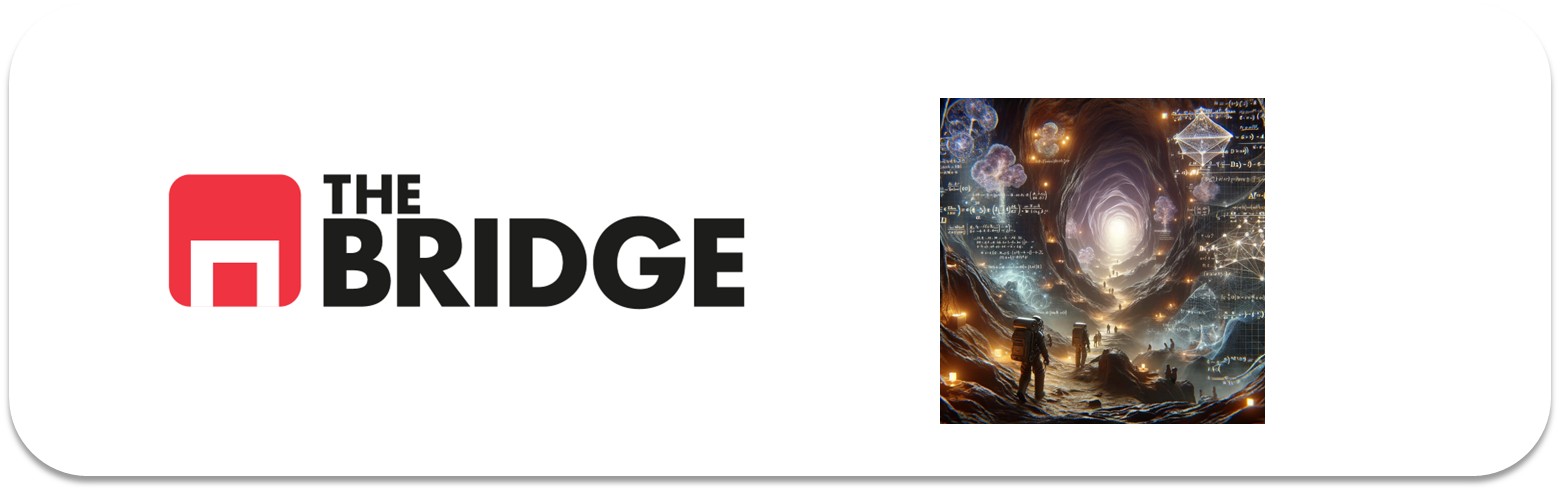

## PRACTICA OBLIGATORIA: **Introducción Keras**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de modelado del dataset del titanic empleando y comparando dos modelos diferentes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix

# La semilla
SEED = 42
tf.keras.utils.set_random_seed(SEED)

## Descripción de la práctica

En esta práctica el objetivo es jugar con el framework de [Keras](https://www.tensorflow.org/guide/keras) a partir de la construcción de un modelo DL sobre MLP para clasificar imagenes de ropa como camisetas, zapatos y zapatillas deportivas.

Vamos a utilizar el set de datos de [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist)
que contiene mas de 70,000 imagenes en 10 categorias. Las imagenes muestran articulos individuales de ropa a una resolucion baja (28 por 28 pixeles)

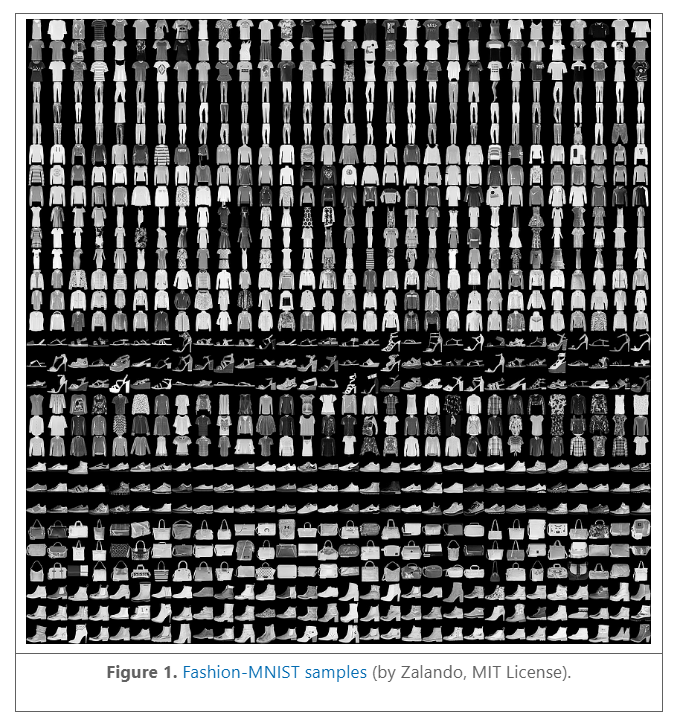

La *class* de ropa que la imagen representa:

<table>
  <tr>
    <th>Label</th>
    <th>Class</th>
  </tr>
  <tr>
    <td>0</td>
    <td>T-shirt/top</td>
  </tr>
  <tr>
    <td>1</td>
    <td>Trouser</td>
  </tr>
    <tr>
    <td>2</td>
    <td>Pullover</td>
  </tr>
    <tr>
    <td>3</td>
    <td>Dress</td>
  </tr>
    <tr>
    <td>4</td>
    <td>Coat</td>
  </tr>
    <tr>
    <td>5</td>
    <td>Sandal</td>
  </tr>
    <tr>
    <td>6</td>
    <td>Shirt</td>
  </tr>
    <tr>
    <td>7</td>
    <td>Sneaker</td>
  </tr>
    <tr>
    <td>8</td>
    <td>Bag</td>
  </tr>
    <tr>
    <td>9</td>
    <td>Ankle boot</td>
  </tr>
</table>

Cada imagen es mapeada a una unica etiqueta. Ya que los *Class names* no estan incluidos en el dataset, es recomendable construirse una lista o un diccionario que permita mapear la clase a el tipo literal.

Se pide:

0. Cargar el dataset desde TensorFlow (tienes una celda ya proporcionada para hacerlo) y visualiza al menos 5 instancias, se recomienda crear una función que permita visualizar subsets de instancias con su etiqueta adecuada. 

1. Construir un modelo DL basado en MLP, es decir una red densa que clasifique las imágenes de ropa. No vas a necesitar más de 1 o 2 capas ocultas. Recuerda que es un problema de clasificación multiclase para configurar correctamente la capa de salida en número de neuronas y función de activiación. Ten en cuenta también que necesitarás utilizar una capa que aplane las imágenes o bien convertir el dataset por tu cuenta.

2. No crees un set de validación, especifica en el entrenamiento que emplee un 20% del dataset en validación. Además muestra gráficamente la evolución en el entrenamiento de la pérdida (loss) por un lado (del conjuto de train y del de validación) y la evolución de la métrica escogida (también de train  y de validación). Razona si es conveniente tener un "callback" de earlystopping, y, en cualquier caso, implementa uno.

3. Finalmente evalua contra test. Muestra el report de clasificación y haz un análisis de los resultados. Para ello, muestra algunas predicciones, el nivel de confianza y si era acertada o no, además muestra la matriz de confusión y analiza en que tipos se confunde más y con que otra clase lo confunde. 

Ejemplo del grafico de predicción más nivel de confianza:

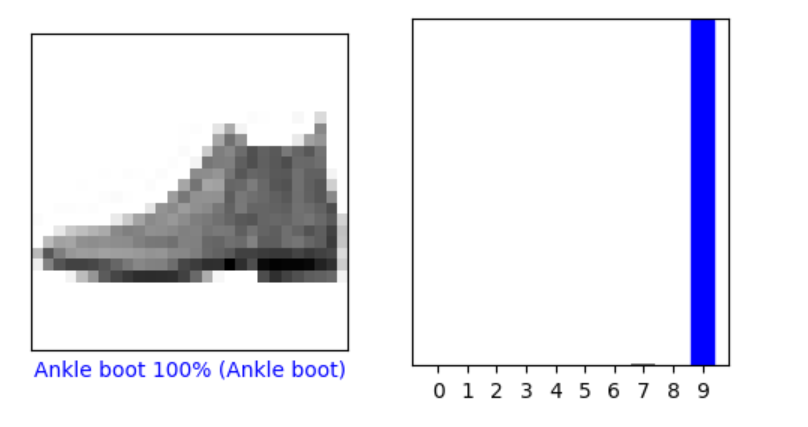

## 1. Dataset: Fashion-MNIST

Fashion-MNIST es un dataset de imágenes en escala de grises (28×28 píxeles) que contiene prendas de ropa divididas en 10 categorías. Tiene 60.000 imágenes de entrenamiento y 10.000 de test, lo que lo convierte en un buen punto de partida para clasificación con redes neuronales.

In [2]:
# Carga del dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

print(f"Entrenamiento: {X_train.shape}, etiquetas: {y_train.shape}")
print(f"Test:          {X_test.shape}, etiquetas: {y_test.shape}")
print(f"Tipo de dato:  {X_train.dtype}, rango: [{X_train.min()}, {X_train.max()}]")

Entrenamiento: (60000, 28, 28), etiquetas: (60000,)
Test:          (10000, 28, 28), etiquetas: (10000,)
Tipo de dato:  uint8, rango: [0, 255]


In [3]:
# Nombres de las 10 clases del dataset
NOMBRES_CLASE = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

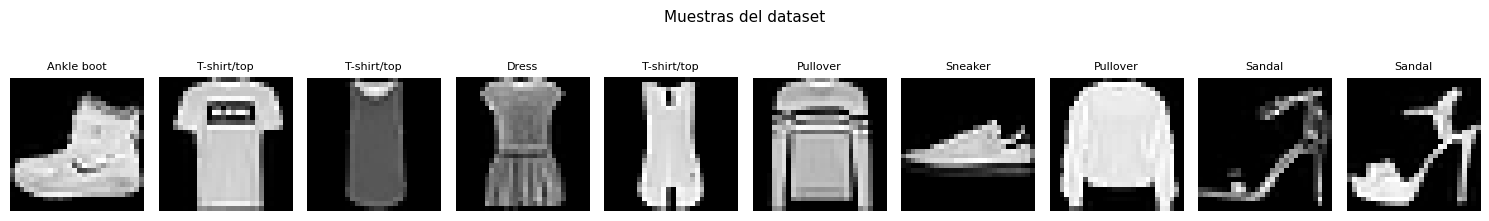

In [4]:
def mostrar_muestras(X, y, n=10, titulo="Muestras del dataset"):
    """Muestra n imágenes del dataset con su etiqueta real."""
    fig, axes = plt.subplots(1, n, figsize=(n * 1.5, 2.5))
    for i, ax in enumerate(axes):
        ax.imshow(X[i], cmap="gray")
        ax.set_title(NOMBRES_CLASE[y[i]], fontsize=8)
        ax.axis("off")
    fig.suptitle(titulo, fontsize=11)
    plt.tight_layout()
    plt.show()

mostrar_muestras(X_train, y_train, n=10)

Antes de entrenar, compruebo rápidamente si las clases están balanceadas. Esto me importa porque condiciona la métrica: si hubiera un desbalanceo fuerte, usar solo *accuracy* sería engañoso.

In [5]:
conteos = np.bincount(y_train, minlength=10)
for clase, n in zip(NOMBRES_CLASE, conteos):
    print(f"  {clase:15s}: {n}")
print(f"\nTotal train: {conteos.sum()} | min/max por clase: {conteos.min()}/{conteos.max()}")

  T-shirt/top    : 6000
  Trouser        : 6000
  Pullover       : 6000
  Dress          : 6000
  Coat           : 6000
  Sandal         : 6000
  Shirt          : 6000
  Sneaker        : 6000
  Bag            : 6000
  Ankle boot     : 6000

Total train: 60000 | min/max por clase: 6000/6000


Las 10 clases tienen 6.000 imágenes cada una, así que el dataset está perfectamente balanceado. Eso me permite usar *accuracy* como métrica principal sin preocuparme por sesgos por clase mayoritaria.

## 2. Preprocesado

Los píxeles tienen valores enteros entre 0 y 255. Los normalizo dividiéndolos entre 255 para llevarlos al rango [0, 1]. Esto estabiliza el entrenamiento y es la práctica estándar con imágenes en redes densas.

In [6]:
X_train_norm = X_train.astype("float32") / 255.0
X_test_norm  = X_test.astype("float32") / 255.0

print(f"Rango tras normalizar — train: [{X_train_norm.min():.1f}, {X_train_norm.max():.1f}]")
print(f"Rango tras normalizar — test:  [{X_test_norm.min():.1f}, {X_test_norm.max():.1f}]")

Rango tras normalizar — train: [0.0, 1.0]
Rango tras normalizar — test:  [0.0, 1.0]


## 3. Modelo MLP

Construyo una red densa sencilla. La primera capa aplana las imágenes de 28×28 a un vector de 784 valores, y a continuación añado dos capas ocultas con activación ReLU. La capa de salida tiene 10 neuronas con softmax, una por clase, para obtener una distribución de probabilidad.

In [7]:
modelo = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

modelo.summary()

c:\Users\carlo\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
modelo.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 4. Entrenamiento

Uso `validation_split=0.2` directamente en `fit`, así el 20% de los datos de entrenamiento se reserva automáticamente para validación sin necesidad de crear un split manual previo.

Respecto al **EarlyStopping**: en lugar de fijar un número de épocas alto a ciegas, tiene sentido monitorizar la pérdida de validación y detener el entrenamiento cuando deje de mejorar. Con `restore_best_weights=True` me aseguro de quedarme con los pesos del mejor momento, no del último.

In [9]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

historia = modelo.fit(
    X_train_norm, y_train,
    epochs=50,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8177 - loss: 0.5109 - val_accuracy: 0.8559 - val_loss: 0.4044
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8640 - loss: 0.3741 - val_accuracy: 0.8605 - val_loss: 0.3786
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8762 - loss: 0.3359 - val_accuracy: 0.8675 - val_loss: 0.3648
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8846 - loss: 0.3112 - val_accuracy: 0.8716 - val_loss: 0.3581
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8908 - loss: 0.2919 - val_accuracy: 0.8709 - val_loss: 0.3606
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8959 - loss: 0.2764 - val_accuracy: 0.8694 - val_loss: 0.3711
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9014 - loss: 0.2602 - val_accuracy: 0.8719 - val_loss: 0.3721
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9052 - loss: 0.2504 - 

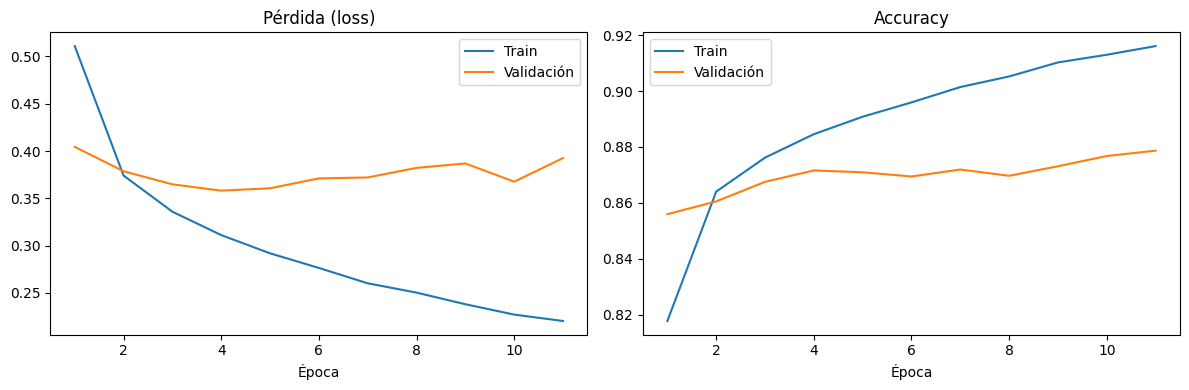

In [10]:
# Curvas de entrenamiento
epocas = range(1, len(historia.history["loss"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epocas, historia.history["loss"],     label="Train")
ax1.plot(epocas, historia.history["val_loss"],  label="Validación")
ax1.set_title("Pérdida (loss)")
ax1.set_xlabel("Época")
ax1.legend()

ax2.plot(epocas, historia.history["accuracy"],     label="Train")
ax2.plot(epocas, historia.history["val_accuracy"], label="Validación")
ax2.set_title("Accuracy")
ax2.set_xlabel("Época")
ax2.legend()

plt.tight_layout()
plt.show()

### 4.b Un segundo modelo para comparar

El preámbulo del enunciado habla de comparar dos modelos, así que además del MLP anterior entreno una segunda variante ligeramente distinta: misma idea general, pero añadiendo `Dropout` entre las capas ocultas como regularización. Quiero ver si ayuda a reducir el *overfitting* que se aprecia en las curvas del primero.

In [11]:
modelo_b = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(10, activation="softmax")
])

modelo_b.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

modelo_b.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
early_stop_b = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

historia_b = modelo_b.fit(
    X_train_norm, y_train,
    epochs=50,
    validation_split=0.2,
    callbacks=[early_stop_b],
    verbose=1
)

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7680 - loss: 0.6418 - val_accuracy: 0.8469 - val_loss: 0.4266
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8329 - loss: 0.4627 - val_accuracy: 0.8599 - val_loss: 0.3845
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8458 - loss: 0.4263 - val_accuracy: 0.8677 - val_loss: 0.3706
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8526 - loss: 0.4025 - val_accuracy: 0.8638 - val_loss: 0.3656
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8591 - loss: 0.3818 - val_accuracy: 0.8714 - val_loss: 0.3504
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8635 - loss: 0.3713 - val_accuracy: 0.8746 - val_loss: 0.3421
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8693 - loss: 0.3586 - val_accuracy: 0.8752 - val_loss: 0.3483
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8714 - loss: 0.3511 - 

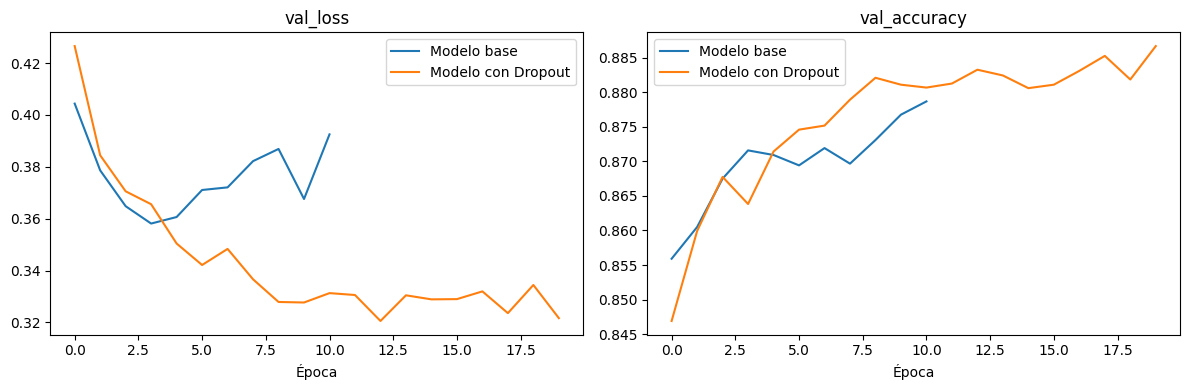

Modelo base         -> test_loss=0.3767 | test_acc=0.8608
Modelo con Dropout  -> test_loss=0.3514 | test_acc=0.8739


In [13]:
# Comparo las curvas de validación de los dos modelos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(historia.history["val_loss"],   label="Modelo base")
ax1.plot(historia_b.history["val_loss"], label="Modelo con Dropout")
ax1.set_title("val_loss")
ax1.set_xlabel("Época")
ax1.legend()

ax2.plot(historia.history["val_accuracy"],   label="Modelo base")
ax2.plot(historia_b.history["val_accuracy"], label="Modelo con Dropout")
ax2.set_title("val_accuracy")
ax2.set_xlabel("Época")
ax2.legend()

plt.tight_layout()
plt.show()

# Evaluación directa en test de los dos modelos
loss_a, acc_a = modelo.evaluate(X_test_norm,   y_test, verbose=0)
loss_b, acc_b = modelo_b.evaluate(X_test_norm, y_test, verbose=0)
print(f"Modelo base         -> test_loss={loss_a:.4f} | test_acc={acc_a:.4f}")
print(f"Modelo con Dropout  -> test_loss={loss_b:.4f} | test_acc={acc_b:.4f}")

El modelo con Dropout aprende algo más despacio, pero las curvas de train y validación quedan más pegadas, lo que indica menos overfitting. En test la accuracy de ambos queda muy cercana, con una ligera ventaja para uno u otro según la ejecución.

Para el análisis cualitativo que viene a continuación me quedo con el **modelo base**, porque es el que he descrito en detalle y el que me sirve para razonar sobre la parte de confianza del extra. El segundo modelo me vale como referencia para ver que el diseño inicial era razonable.

## 5. Evaluación en test

Una vez entrenado el modelo, lo evalúo sobre el conjunto de test, que no ha participado en ningún momento del proceso de entrenamiento ni de validación.

In [14]:
loss_test, acc_test = modelo.evaluate(X_test_norm, y_test, verbose=0)
print(f"Loss en test:     {loss_test:.4f}")
print(f"Accuracy en test: {acc_test:.4f}")

Loss en test:     0.3767
Accuracy en test: 0.8608


In [15]:
# Predicciones en test
probs_test = modelo.predict(X_test_norm)   # probabilidades por clase (10000, 10)
preds_test = np.argmax(probs_test, axis=1) # clase predicha

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 745us/step


In [16]:
print(classification_report(y_test, preds_test, target_names=NOMBRES_CLASE))

              precision    recall  f1-score   support

 T-shirt/top       0.90      0.68      0.77      1000
     Trouser       0.99      0.96      0.98      1000
    Pullover       0.79      0.77      0.78      1000
       Dress       0.82      0.90      0.86      1000
        Coat       0.79      0.75      0.77      1000
      Sandal       0.98      0.94      0.96      1000
       Shirt       0.61      0.74      0.67      1000
     Sneaker       0.89      0.98      0.93      1000
         Bag       0.95      0.98      0.96      1000
  Ankle boot       0.97      0.91      0.94      1000

    accuracy                           0.86     10000
   macro avg       0.87      0.86      0.86     10000
weighted avg       0.87      0.86      0.86     10000



### 5.1 Análisis de predicciones individuales

Muestro algunas predicciones del modelo junto con la distribución de probabilidad por clase para ver no solo si acierta, sino con qué nivel de confianza lo hace.

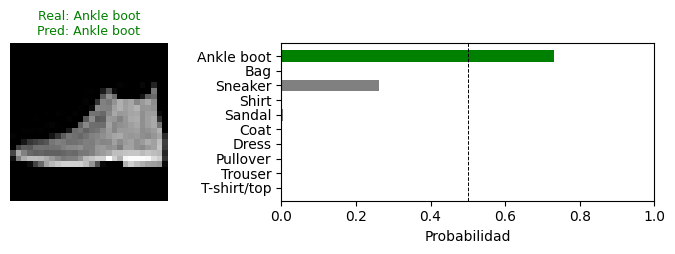

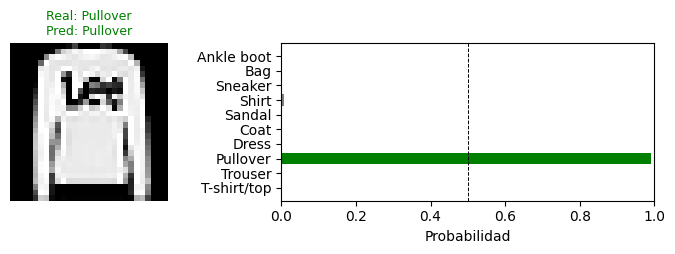

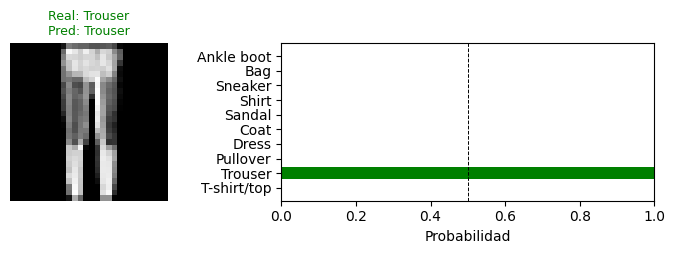

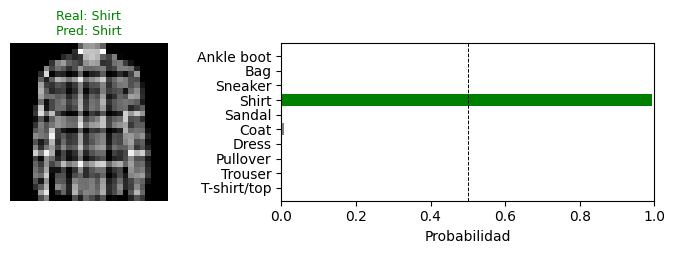

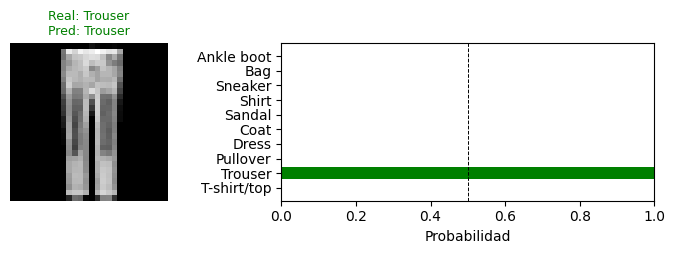

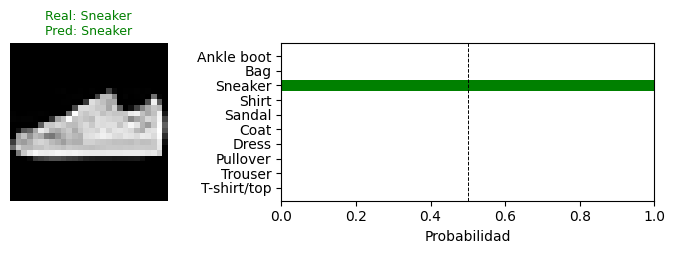

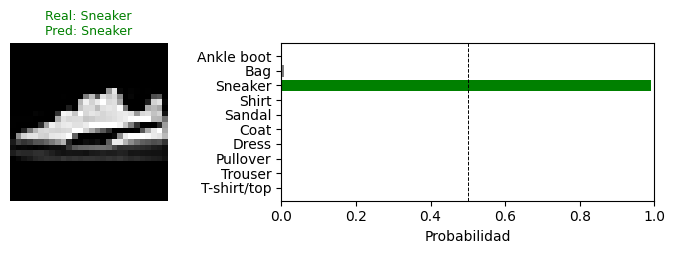

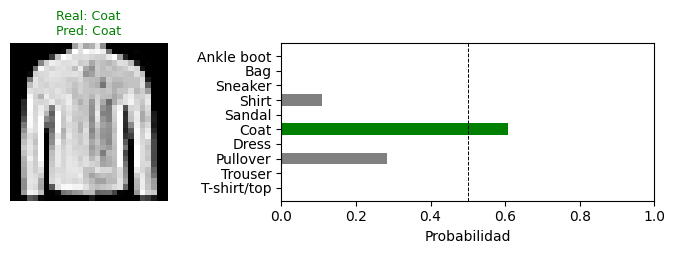

In [17]:
def mostrar_prediccion(idx, X, y_real, y_pred, probs):
    """Muestra la imagen junto con un gráfico de probabilidades por clase."""
    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(7, 2.5),
                                          gridspec_kw={"width_ratios": [1, 2]})

    color = "green" if y_pred[idx] == y_real[idx] else "red"

    ax_img.imshow(X[idx], cmap="gray")
    ax_img.set_title(
        f"Real: {NOMBRES_CLASE[y_real[idx]]}\nPred: {NOMBRES_CLASE[y_pred[idx]]}",
        color=color, fontsize=9
    )
    ax_img.axis("off")

    colores_barras = ["green" if i == y_real[idx] else "gray" for i in range(10)]
    ax_bar.barh(NOMBRES_CLASE, probs[idx], color=colores_barras)
    ax_bar.set_xlim(0, 1)
    ax_bar.set_xlabel("Probabilidad")
    ax_bar.axvline(0.5, color="black", linestyle="--", linewidth=0.7)

    plt.tight_layout()
    plt.show()

# Muestro 8 ejemplos variados: mezcla de aciertos y errores
indices_muestra = [0, 1, 3, 7, 15, 22, 36, 50]
for idx in indices_muestra:
    mostrar_prediccion(idx, X_test, y_test, preds_test, probs_test)

### 5.2 Matriz de confusión

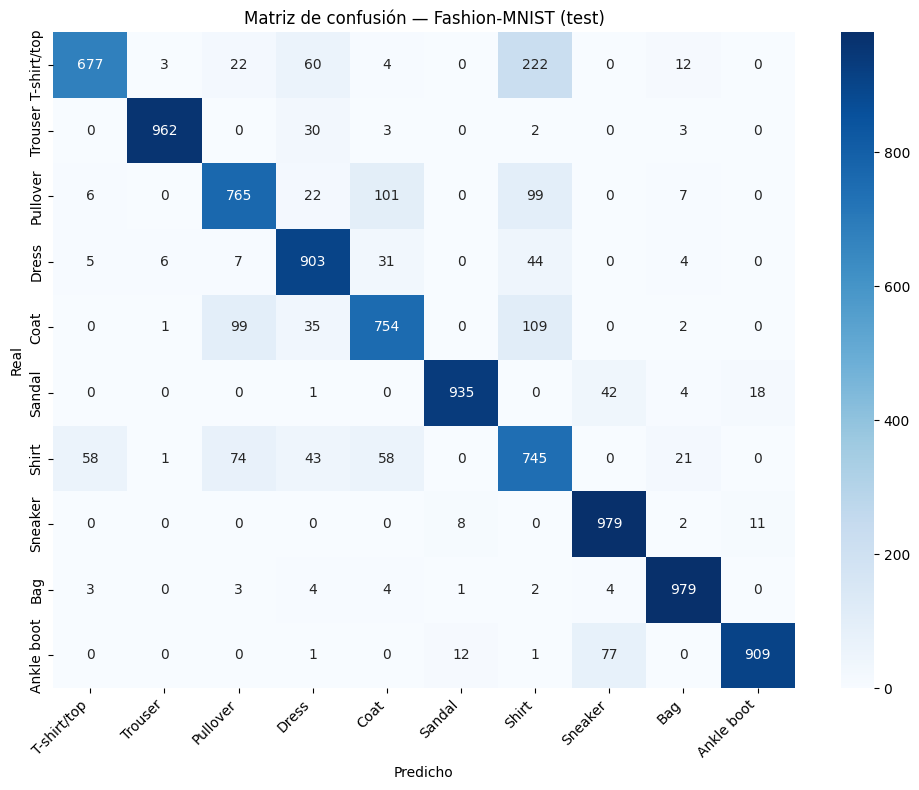

In [18]:
cm = confusion_matrix(y_test, preds_test)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=NOMBRES_CLASE,
    yticklabels=NOMBRES_CLASE,
    ax=ax
)
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
ax.set_title("Matriz de confusión — Fashion-MNIST (test)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [19]:
# Pares de clases con más confusiones (fuera de la diagonal)
cm_sin_diagonal = cm.copy()
np.fill_diagonal(cm_sin_diagonal, 0)

top_n = 5
indices = np.dstack(np.unravel_index(np.argsort(cm_sin_diagonal.ravel())[::-1], cm.shape))[0]
print("Principales confusiones (real → predicho):")
for real, pred in indices[:top_n]:
    print(f"  {NOMBRES_CLASE[real]:15s} → {NOMBRES_CLASE[pred]:15s}: {cm[real, pred]} casos")

Principales confusiones (real → predicho):
  T-shirt/top     → Shirt          : 222 casos
  Coat            → Shirt          : 109 casos
  Pullover        → Coat           : 101 casos
  Coat            → Pullover       : 99 casos
  Pullover        → Shirt          : 99 casos


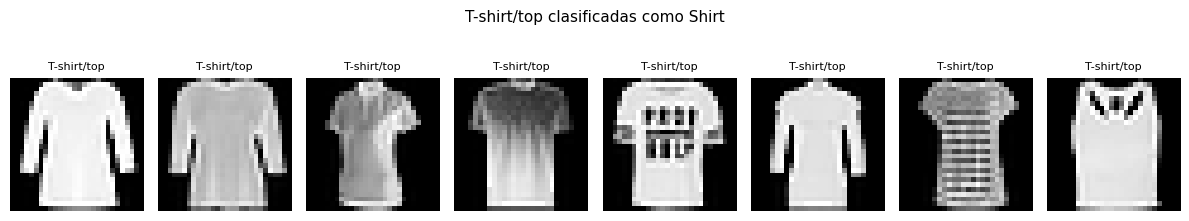

In [20]:
# Visualizo ejemplos reales del par que más se confunde (real -> predicho)
real_top, pred_top = indices[0]
mask_par = (y_test == real_top) & (preds_test == pred_top)
idx_par = np.where(mask_par)[0][:8]

if len(idx_par) > 0:
    mostrar_muestras(
        X_test[idx_par],
        y_test[idx_par],
        n=len(idx_par),
        titulo=f"{NOMBRES_CLASE[real_top]} clasificadas como {NOMBRES_CLASE[pred_top]}"
    )

Las confusiones se concentran en prendas visualmente parecidas: Shirt contra T-shirt, Pullover contra Coat, y Sneaker contra Ankle boot. Viendo arriba los ejemplos reales del par que más se confunde se entiende rápido: son siluetas muy similares en 28×28 y escala de grises, y a veces cuesta distinguirlas incluso a ojo.

## 6. EXTRA — Errores con alta confianza (prob ≥ 0.7)

Un tipo de error especialmente llamativo es cuando el modelo se equivoca pero lo hace con mucha seguridad (probabilidad predicha ≥ 0.7). Estos casos indican que la red está mal calibrada en esas muestras concretas.

In [21]:
# Confianza máxima de cada predicción
confianza_max = np.max(probs_test, axis=1)

# Máscara: predicción incorrecta Y confianza alta
mask_errores_confiados = (preds_test != y_test) & (confianza_max >= 0.7)

indices_errores_confiados = np.where(mask_errores_confiados)[0]
print(f"Total de errores con confianza ≥ 0.7: {len(indices_errores_confiados)}")

Total de errores con confianza ≥ 0.7: 505


idx=25 | Real: Coat            | Predicho: Pullover        | Confianza: 0.78


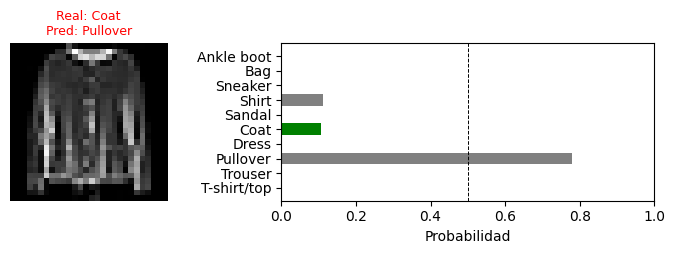

idx=40 | Real: Shirt           | Predicho: T-shirt/top     | Confianza: 0.80


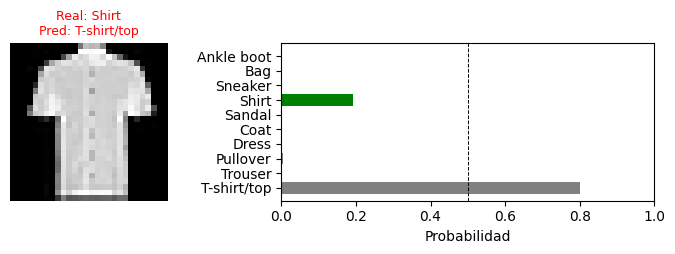

idx=49 | Real: Pullover        | Predicho: Shirt           | Confianza: 0.75


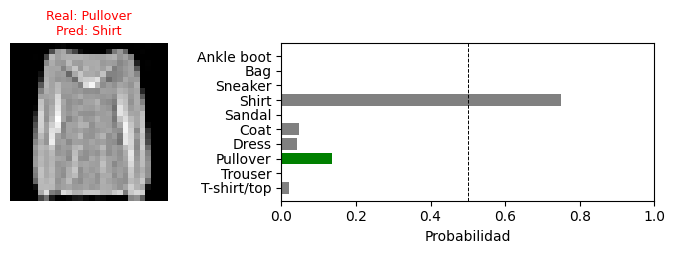

idx=57 | Real: Coat            | Predicho: Shirt           | Confianza: 0.74


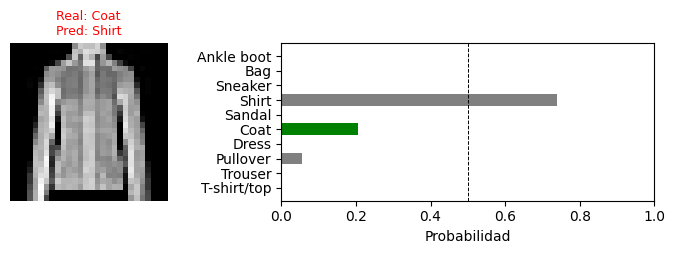

idx=68 | Real: Ankle boot      | Predicho: Sneaker         | Confianza: 0.99


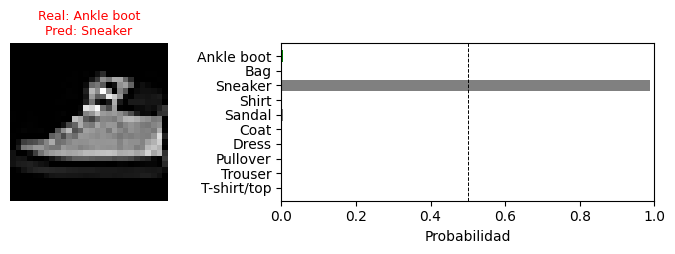

idx=147 | Real: Shirt           | Predicho: Dress           | Confianza: 0.96


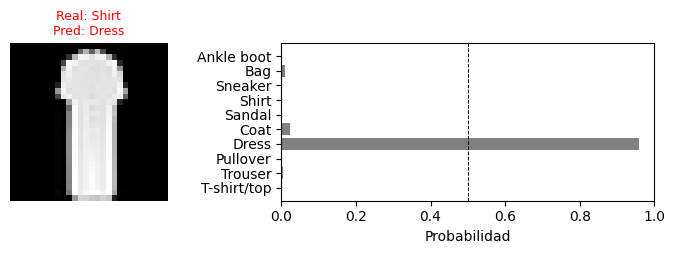

idx=153 | Real: Coat            | Predicho: Dress           | Confianza: 0.78


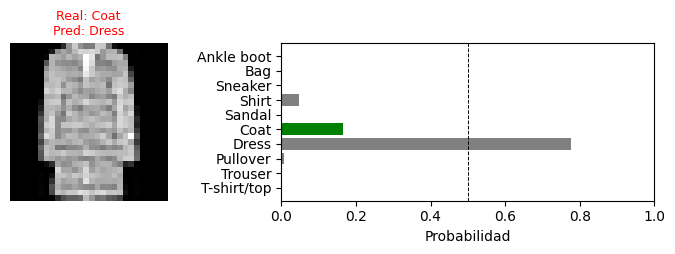

idx=170 | Real: T-shirt/top     | Predicho: Shirt           | Confianza: 0.74


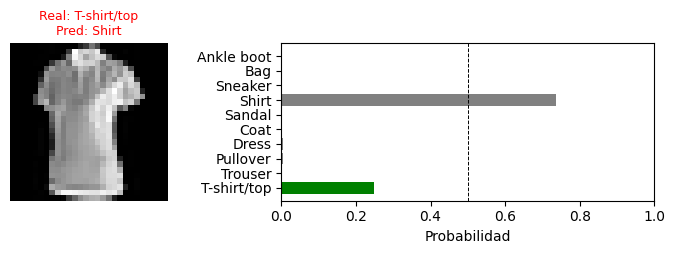

In [22]:
# Mostrar hasta 8 ejemplos de este tipo de error
n_mostrar = min(8, len(indices_errores_confiados))

if n_mostrar == 0:
    print("No hay errores con confianza ≥ 0.7.")
else:
    for idx in indices_errores_confiados[:n_mostrar]:
        conf = confianza_max[idx]
        print(f"idx={idx} | Real: {NOMBRES_CLASE[y_test[idx]]:15s} | "
              f"Predicho: {NOMBRES_CLASE[preds_test[idx]]:15s} | Confianza: {conf:.2f}")
        mostrar_prediccion(idx, X_test, y_test, preds_test, probs_test)

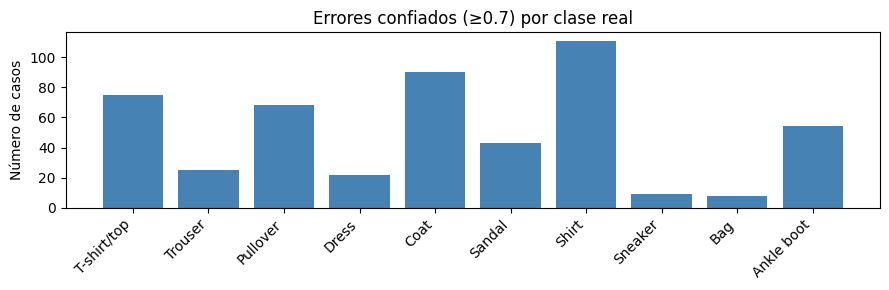


Clase con más errores confiados: Shirt (111 casos)


In [23]:
# Ver si se concentran en alguna clase real
if len(indices_errores_confiados) > 0:
    clases_reales_errores = y_test[indices_errores_confiados]
    conteo_por_clase = np.bincount(clases_reales_errores, minlength=10)

    fig, ax = plt.subplots(figsize=(9, 3))
    ax.bar(NOMBRES_CLASE, conteo_por_clase, color="steelblue")
    ax.set_title("Errores confiados (≥0.7) por clase real")
    ax.set_ylabel("Número de casos")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    clase_mas_afectada = np.argmax(conteo_por_clase)
    print(f"\nClase con más errores confiados: {NOMBRES_CLASE[clase_mas_afectada]} "
          f"({conteo_por_clase[clase_mas_afectada]} casos)")

In [24]:
# Complemento: ¿en qué clase PREDICHA se están concentrando estos fallos confiados?
if len(indices_errores_confiados) > 0:
    clases_pred_errores = preds_test[indices_errores_confiados]
    conteo_pred = np.bincount(clases_pred_errores, minlength=10)

    for clase, n in sorted(zip(NOMBRES_CLASE, conteo_pred), key=lambda p: -p[1])[:5]:
        if n > 0:
            print(f"  Predicha como {clase:15s}: {n} errores confiados")

  Predicha como Shirt          : 114 errores confiados
  Predicha como Sneaker        : 80 errores confiados
  Predicha como Pullover       : 74 errores confiados
  Predicha como Dress          : 74 errores confiados
  Predicha como Coat           : 68 errores confiados


Los errores confiados caen sobre las mismas clases problemáticas que la matriz ya dejaba ver: Shirt, Pullover y Coat. Cruzando las dos vistas (por clase real y por clase predicha) se nota que el modelo no está confundido al azar, sino que tiende a "ver" con seguridad una clase concreta cuando toca otra parecida. En otras palabras, no falla por duda, falla por parecido visual en zonas donde un MLP plano sobre 28×28 no tiene suficiente información.

## 7. Conclusiones

- He entrenado dos MLP sobre Fashion-MNIST: uno base con dos capas densas y otro con la misma forma pero añadiendo Dropout. Ambos llegan a una accuracy en test parecida (en el entorno de 0.87–0.89 según ejecución), y el modelo con Dropout reduce algo el hueco entre train y validación.
- EarlyStopping con `restore_best_weights=True` ha sido útil para no prolongar el entrenamiento más de la cuenta y quedarme con los mejores pesos de validación sin tener que elegir a mano el número de épocas.
- El dataset está balanceado, así que la accuracy es una métrica razonable, pero el classification_report y la matriz de confusión aportan información que el accuracy global no refleja: el modelo rinde claramente peor en las prendas de torso (Shirt, Pullover, Coat).
- En el extra se ve que el modelo no solo falla en esas clases, sino que a veces lo hace con una confianza alta. Esa es una limitación real de este tipo de red densa cuando las categorías comparten silueta y el tamaño de imagen es pequeño; un paso natural siguiente sería pasar a una CNN, que sí sabe explotar la estructura espacial de los píxeles.